# Lección 4: Procesamiento de datos estructurados — Spark SQL y DataFrames

**Proyecto:** Retail Analytics Pipeline — Módulo 9  
**Empresa ficticia:** RetailMax (e-commerce de moda)  
**Dataset:** Fashion-MNIST (70,000 imágenes de prendas de ropa)  

---

## 📋 Recap de la Lección 3

En la **Lección 3** trabajamos con **RDDs (Resilient Distributed Datasets)**:

| Concepto | Lo que vimos |
|---|---|
| `map()` | Transformar cada elemento (ej: normalizar píxeles) |
| `filter()` | Filtrar por condición (ej: solo clase 0) |
| `flatMap()` | Aplanar estructuras anidadas |
| `sortBy()` | Ordenar por clave |
| DAG | Grafo de ejecución diferida |

**Limitación de los RDDs:** Son potentes, pero trabajan con objetos Python sin estructura fija. Spark no sabe qué hay *dentro* de cada elemento, así que no puede optimizar automáticamente las consultas.

---

## 🔄 ¿Qué cambia con DataFrames?

Los **DataFrames** añaden una capa de **estructura** sobre los RDDs:

```
RDD:          [objeto, objeto, objeto, ...]   ← Spark no sabe el tipo
DataFrame:    [fila con columnas tipadas, ...]  ← Spark conoce el schema
```

Gracias a ese schema, el optimizador **Catalyst** puede reescribir y optimizar el plan de ejecución automáticamente, igual que un motor de base de datos.

---

## 🔗 Conexión con la Lección 5

Al final de esta lección guardaremos los datos procesados en **formato Parquet**. En la **Lección 5** cargaremos ese Parquet directamente para construir el pipeline de **MLlib** (Machine Learning distribuido). El DataFrame estructurado que creamos hoy es la entrada perfecta para MLlib.

---

## 🗺️ Mapa de la lección

```
Sección 0: Configuración inicial
    ↓
Sección 1: De RDD a DataFrame — Esquemas explícitos
    ↓
Sección 2: Operaciones básicas con DataFrame API
    ↓
Sección 3: Spark SQL — Vistas temporales y consultas
    ↓
Sección 4: Métricas de negocio RetailMax
    ↓
Sección 5: Optimización — Catalyst y particionamiento
    ↓
Sección 6: Guardar en formato Parquet
    ↓
Sección 7: Guardar métricas en Parquet
    ↓
Sección 8: Cierre e informe final
```

---
## Sección 0: Configuración inicial

Importamos las librerías necesarias, creamos la **SparkSession** y cargamos el dataset Fashion-MNIST.  
La SparkSession es el punto de entrada único para toda la funcionalidad de Spark 2.x+.

In [2]:
# ============================================================
# SECCIÓN 0: Configuración inicial
# ============================================================

# --- 0.1 Importaciones de PySpark ---
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType,    # Define la estructura completa del DataFrame
    StructField,   # Define cada campo (columna) del schema
    StringType,    # Tipo string de Spark
    IntegerType,   # Tipo entero de Spark
    FloatType,     # Tipo float de Spark
    ArrayType      # Tipo array (lista) de Spark — no lo usaremos para píxeles
)
import pyspark.sql.functions as F  # Funciones de Spark SQL (col, when, avg, count, etc.)

# --- 0.2 Importaciones estándar ---
import numpy as np          # Operaciones numéricas sobre arrays de píxeles
import pandas as pd         # Para toPandas() y visualización de resultados
import matplotlib.pyplot as plt  # Visualizaciones
import matplotlib.cm as cm       # Colormaps para gráficos
import os                   # Manejo de rutas y archivos
import shutil               # Para eliminar carpetas (shutil.rmtree)
import time                 # Para medir tiempos de ejecución

print("Librerías importadas correctamente")

# --- 0.3 Crear SparkSession ---
# Usamos los mismos parámetros que en las lecciones anteriores
spark = (
    SparkSession.builder
    .appName("RetailMax-Leccion4-DataFrames")   # Nombre del job en la Spark UI
    .master("local[*]")                          # Usar todos los cores disponibles
    .config("spark.driver.memory", "2g")         # Memoria del driver
    .config("spark.sql.shuffle.partitions", "4") # Particiones para operaciones de shuffle
    .config("spark.ui.showConsoleProgress", "false")  # Suprimir barras de progreso
    .getOrCreate()
)

# Reducir verbosidad de los logs de Spark
spark.sparkContext.setLogLevel("ERROR")

print(f"SparkSession creada — Versión de Spark: {spark.version}")
print(f"  AppName: {spark.sparkContext.appName}")
print(f"  Master:  {spark.sparkContext.master}")

# --- 0.4 Mapeo de etiquetas: número → nombre de categoría ---
# Fashion-MNIST tiene 10 clases de prendas de ropa
LABEL_NAMES = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

print(f"\nCategorías de Fashion-MNIST:")
for k, v in LABEL_NAMES.items():
    print(f"   [{k}] {v}")

Librerías importadas correctamente
SparkSession creada — Versión de Spark: 4.1.1
  AppName: RetailMax-Leccion4-DataFrames
  Master:  local[*]

Categorías de Fashion-MNIST:
   [0] T-shirt/top
   [1] Trouser
   [2] Pullover
   [3] Dress
   [4] Coat
   [5] Sandal
   [6] Shirt
   [7] Sneaker
   [8] Bag
   [9] Ankle boot


In [4]:
# ============================================================
# SECCIÓN 0 (cont.): Carga de Fashion-MNIST
# ============================================================
# Intentamos cargar el dataset por varios métodos en orden de preferencia.
# Cada imagen es un array de 784 valores uint8 (28×28 píxeles).
# NO almacenaremos los 784 píxeles en el DataFrame; solo calcularemos
# estadísticas resumidas por imagen.

X_train, y_train = None, None
X_test, y_test   = None, None
carga_exitosa    = False
metodo_carga     = ""

# --- Método 1: TensorFlow/Keras ---
if not carga_exitosa:
    try:
        import tensorflow as tf
        (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
        carga_exitosa = True
        metodo_carga  = "TensorFlow/Keras"
        print("Fashion-MNIST cargado con TensorFlow/Keras")
    except Exception as e:
        print(f"  TensorFlow no disponible: {e}")

# --- Método 2: PyTorch / torchvision ---
if not carga_exitosa:
    try:
        import torchvision.datasets as dsets
        import torchvision.transforms as transforms
        transform = transforms.ToTensor()
        train_ds = dsets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
        test_ds  = dsets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
        X_train  = np.array([img.numpy().reshape(28, 28) for img, _ in train_ds])
        y_train  = np.array([label for _, label in train_ds])
        X_test   = np.array([img.numpy().reshape(28, 28) for img, _ in test_ds])
        y_test   = np.array([label for _, label in test_ds])
        # Escalar de [0,1] a [0,255] para consistencia
        X_train  = (X_train * 255).astype(np.uint8)
        X_test   = (X_test  * 255).astype(np.uint8)
        carga_exitosa = True
        metodo_carga  = "PyTorch/torchvision"
        print("Fashion-MNIST cargado con PyTorch/torchvision")
    except Exception as e:
        print(f"  PyTorch no disponible: {e}")

# --- Método 3: scikit-learn (fetch_openml) ---
if not carga_exitosa:
    try:
        from sklearn.datasets import fetch_openml
        print("  Descargando Fashion-MNIST desde OpenML (puede tardar 1-2 min)...")
        dataset = fetch_openml(name="Fashion-MNIST", version=1, as_frame=False)
        X_all   = dataset.data.reshape(-1, 28, 28).astype(np.uint8)
        y_all   = dataset.target.astype(int)
        # División estándar: 60,000 train / 10,000 test
        X_train, y_train = X_all[:60000], y_all[:60000]
        X_test,  y_test  = X_all[60000:], y_all[60000:]
        carga_exitosa = True
        metodo_carga  = "scikit-learn/OpenML"
        print("Fashion-MNIST cargado con scikit-learn/OpenML")
    except Exception as e:
        print(f"  scikit-learn no disponible: {e}")

# --- Método 4: Datos sintéticos (fallback garantizado) ---
if not carga_exitosa:
    print("  Generando datos sintéticos que replican la estructura de Fashion-MNIST...")
    np.random.seed(42)
    n_train, n_test = 60000, 10000
    # Cada clase tiene un brillo base ligeramente diferente para realismo
    X_train = np.zeros((n_train, 28, 28), dtype=np.uint8)
    y_train = np.array([i % 10 for i in range(n_train)])
    for i in range(n_train):
        clase_base = y_train[i] * 25  # Brillo base por clase (0-225)
        ruido      = np.random.randint(0, 50, (28, 28))
        X_train[i] = np.clip(clase_base + ruido, 0, 255).astype(np.uint8)
    X_test  = np.zeros((n_test, 28, 28), dtype=np.uint8)
    y_test  = np.array([i % 10 for i in range(n_test)])
    for i in range(n_test):
        clase_base = y_test[i] * 25
        ruido      = np.random.randint(0, 50, (28, 28))
        X_test[i]  = np.clip(clase_base + ruido, 0, 255).astype(np.uint8)
    carga_exitosa = True
    metodo_carga  = "Sintético (fallback)"
    print("Datos sintéticos generados")

# --- Verificación de dimensiones ---
print(f"\nResumen del dataset ({metodo_carga}):")
print(f"   X_train: {X_train.shape}  — {X_train.shape[0]:,} imágenes de {X_train.shape[1]}×{X_train.shape[2]} px")
print(f"   X_test:  {X_test.shape}   — {X_test.shape[0]:,}  imágenes de {X_test.shape[1]}×{X_test.shape[2]} px")
print(f"   Clases:  {np.unique(y_train)}")

Fashion-MNIST cargado con TensorFlow/Keras

Resumen del dataset (TensorFlow/Keras):
   X_train: (60000, 28, 28)  — 60,000 imágenes de 28×28 px
   X_test:  (10000, 28, 28)   — 10,000  imágenes de 28×28 px
   Clases:  [0 1 2 3 4 5 6 7 8 9]


In [5]:
# ============================================================
# SECCIÓN 0 (cont.): Preparar lista de filas para el DataFrame
# ============================================================
# Convertimos cada imagen en una FILA con estadísticas de sus píxeles.
# ¿Por qué estadísticas y no los 784 píxeles?
#   → Un DataFrame con 70,000 filas × 784 columnas sería enorme y difícil de manejar.
#   → Con pixel_mean, pixel_std, pixel_max, pixel_min capturamos la esencia de la imagen.
#   → Esto es una técnica real de Feature Engineering llamada "resumen estadístico".
#
# SCHEMA que vamos a usar:
#   image_id   (int)   — identificador único de la imagen (0, 1, 2, ...)
#   label      (int)   — etiqueta numérica de la clase (0-9)
#   label_name (str)   — nombre de la categoría ("T-shirt/top", "Sneaker", ...)
#   pixel_mean (float) — brillo promedio de la imagen (0.0 a 255.0)
#   pixel_std  (float) — desviación estándar de los píxeles (contraste)
#   pixel_max  (float) — valor máximo de píxel (zonas más brillantes)
#   pixel_min  (float) — valor mínimo de píxel (zonas más oscuras)
#   split      (str)   — partición: "train" o "test"

print("Preparando lista de filas (esto puede tardar 10-20 segundos)...")
t0   = time.time()
rows = []  # Lista donde acumularemos todas las filas

# --- Procesar imágenes de ENTRENAMIENTO ---
for idx in range(len(X_train)):
    img   = X_train[idx].flatten().astype(np.float32)  # Aplanar 28×28 → 784 valores
    label = int(y_train[idx])
    rows.append((
        idx,                          # image_id único
        label,                        # etiqueta numérica
        LABEL_NAMES[label],           # nombre de la categoría
        float(np.mean(img)),          # pixel_mean
        float(np.std(img)),           # pixel_std
        float(np.max(img)),           # pixel_max
        float(np.min(img)),           # pixel_min
        "train"                       # split
    ))

# --- Procesar imágenes de TEST ---
for idx in range(len(X_test)):
    img   = X_test[idx].flatten().astype(np.float32)
    label = int(y_test[idx])
    rows.append((
        len(X_train) + idx,           # image_id continúa desde donde paró train
        label,
        LABEL_NAMES[label],
        float(np.mean(img)),
        float(np.std(img)),
        float(np.max(img)),
        float(np.min(img)),
        "test"
    ))

t1 = time.time()
print(f"Lista de filas preparada en {t1 - t0:.2f} segundos")
print(f"  Total de filas: {len(rows):,}  (60,000 train + 10,000 test)")
print(f"\nEjemplo de una fila (imagen 0):")
print(f"  image_id   = {rows[0][0]}")
print(f"  label      = {rows[0][1]}")
print(f"  label_name = '{rows[0][2]}'")
print(f"  pixel_mean = {rows[0][3]:.4f}")
print(f"  pixel_std  = {rows[0][4]:.4f}")
print(f"  pixel_max  = {rows[0][5]:.0f}")
print(f"  pixel_min  = {rows[0][6]:.0f}")
print(f"  split      = '{rows[0][7]}'")

Preparando lista de filas (esto puede tardar 10-20 segundos)...
Lista de filas preparada en 1.95 segundos
  Total de filas: 70,000  (60,000 train + 10,000 test)

Ejemplo de una fila (imagen 0):
  image_id   = 0
  label      = 9
  label_name = 'Ankle boot'
  pixel_mean = 97.2538
  pixel_std  = 101.7923
  pixel_max  = 255
  pixel_min  = 0
  split      = 'train'


---
## Sección 1: De RDD a DataFrame — Esquemas explícitos

### ¿Por qué DataFrames?

Cuando trabajamos con **RDDs**, Spark trata cada elemento como una caja negra:  
```python
rdd = sc.parallelize([(0, 'T-shirt', 72.3), (1, 'Bag', 51.8)])  # Spark no sabe qué hay dentro
```

Con **DataFrames**, Spark conoce el **schema** — el nombre y tipo de cada columna — y puede:
1. **Optimizar automáticamente** el plan de ejecución (Catalyst Optimizer)
2. **Predicar columnas** (pushdown): leer solo las columnas necesarias
3. **Usar SQL** estándar para consultas
4. **Interoperar** con pandas, Parquet, Hive, JDBC, etc.

---

### Comparativa: RDD vs DataFrame vs Dataset

| Característica | RDD | DataFrame | Dataset (Scala/Java) |
|---|---|---|---|
| Tipado | Python nativo | Schema explícito | Tipado estático |
| Optimización | Manual | Catalyst automático | Catalyst automático |
| SQL | No | Sí | Sí |
| Interop pandas | Manual | `toPandas()` | No aplica en PySpark |
| Velocidad (típica) | Base | 2-5× más rápido | Similar a DataFrame |
| Disponible en Python | Sí | Sí | No (Python usa DataFrame) |

---

### Concepto de Schema

Un **schema** define la estructura del DataFrame: qué columnas tiene y qué tipo tiene cada una.

```
Schema de fashion_data:
  ├── image_id   : IntegerType   ← 0, 1, 2, ..., 69999
  ├── label      : IntegerType   ← 0, 1, 2, ..., 9
  ├── label_name : StringType    ← "T-shirt/top", "Sneaker", ...
  ├── pixel_mean : FloatType     ← 0.0 a 255.0
  ├── pixel_std  : FloatType     ← 0.0 a 127.5 (aprox)
  ├── pixel_max  : FloatType     ← 0.0 a 255.0
  ├── pixel_min  : FloatType     ← 0.0 a 255.0
  └── split      : StringType    ← "train" o "test"
```

Definir el schema **explícitamente** (en lugar de dejarlo inferir) es una buena práctica en producción: evita errores de tipo y es mucho más rápido.

In [6]:
# ============================================================
# SECCIÓN 1: De RDD a DataFrame — Esquemas explícitos
# ============================================================

# --- Paso 1: Definir el schema explícito ---
# StructType es el contenedor de todos los campos.
# StructField(nombre, tipo, nullable) define cada columna.
schema = StructType([
    StructField("image_id",   IntegerType(), nullable=False),  # ID único, nunca nulo
    StructField("label",      IntegerType(), nullable=False),  # Etiqueta numérica
    StructField("label_name", StringType(),  nullable=False),  # Nombre de categoría
    StructField("pixel_mean", FloatType(),   nullable=False),  # Brillo promedio
    StructField("pixel_std",  FloatType(),   nullable=False),  # Desviación estándar
    StructField("pixel_max",  FloatType(),   nullable=False),  # Píxel más brillante
    StructField("pixel_min",  FloatType(),   nullable=False),  # Píxel más oscuro
    StructField("split",      StringType(),  nullable=False),  # "train" o "test"
])

print(" Schema definido:")
for field in schema.fields:
    print(f"   {field.name:12s} → {field.dataType}  (nullable={field.nullable})")

# --- Paso 2: Crear DataFrame desde la lista de Python ---
# spark.createDataFrame(data, schema) distribuye los datos entre los workers
# y aplica el schema para que Spark conozca los tipos de columna.
print("\nCreando DataFrame (esto puede tardar unos segundos)...")
t0 = time.time()
df = spark.createDataFrame(rows, schema=schema)
t1 = time.time()
print(f"DataFrame creado en {t1 - t0:.2f} segundos")

# --- Paso 3: Mostrar el schema con printSchema() ---
# printSchema() imprime el árbol de columnas con sus tipos.
print("\nEsquema del DataFrame:")
df.printSchema()

# --- Paso 4: Mostrar las primeras 5 filas ---
# show(n) activa una acción: Spark ejecuta el DAG y materializa n filas.
print("Primeras 5 filas del DataFrame:")
df.show(5, truncate=False)

# --- Paso 5: Dimensiones del DataFrame ---
n_filas   = df.count()          # Acción: cuenta todas las filas
n_columnas = len(df.columns)    # Número de columnas (atributo inmediato, no acción)
print(f"\nDimensiones: {n_filas:,} filas × {n_columnas} columnas")
print(f"Columnas: {df.columns}")

# --- Paso 6: Estadísticas generales ---
# describe() calcula count, mean, stddev, min, max para columnas numéricas.
print("\nEstadísticas generales (columnas numéricas):")
df.describe(["pixel_mean", "pixel_std", "pixel_max", "pixel_min"]).show()

 Schema definido:
   image_id     → IntegerType()  (nullable=False)
   label        → IntegerType()  (nullable=False)
   label_name   → StringType()  (nullable=False)
   pixel_mean   → FloatType()  (nullable=False)
   pixel_std    → FloatType()  (nullable=False)
   pixel_max    → FloatType()  (nullable=False)
   pixel_min    → FloatType()  (nullable=False)
   split        → StringType()  (nullable=False)

Creando DataFrame (esto puede tardar unos segundos)...
DataFrame creado en 1.28 segundos

Esquema del DataFrame:
root
 |-- image_id: integer (nullable = false)
 |-- label: integer (nullable = false)
 |-- label_name: string (nullable = false)
 |-- pixel_mean: float (nullable = false)
 |-- pixel_std: float (nullable = false)
 |-- pixel_max: float (nullable = false)
 |-- pixel_min: float (nullable = false)
 |-- split: string (nullable = false)

Primeras 5 filas del DataFrame:
+--------+-----+-----------+----------+----------+---------+---------+-----+
|image_id|label|label_name |pixel_me

---
## Sección 2: Operaciones básicas con DataFrame API

### Dos formas de operar sobre un DataFrame

**1. DataFrame API** — operaciones encadenadas en Python:
```python
df.filter(df.label == 0).groupBy("label_name").agg(F.avg("pixel_mean"))
```

**2. Spark SQL** — consultas SQL puras (Sección 3):
```sql
SELECT label_name, AVG(pixel_mean) FROM fashion_data WHERE label = 0
```

Ambas producen **exactamente el mismo plan de ejecución** por debajo — Catalyst las optimiza igual. La elección es cuestión de preferencia y contexto:

| Situación | Recomendación |
|---|---|
| Transformaciones complejas con lógica Python | DataFrame API |
| Consultas ad-hoc, analistas de negocio | Spark SQL |
| Integración con herramientas BI (Tableau, PowerBI) | Spark SQL |
| Pipelines de ML en producción | DataFrame API |
| Reportes comprensibles para no-programadores | Spark SQL |

In [7]:
# ============================================================
# SECCIÓN 2: Operaciones básicas con DataFrame API
# ============================================================

# --- Paso 1: select() — seleccionar un subconjunto de columnas ---
# Equivalente a SELECT en SQL. Spark NO copia los datos; solo ajusta el plan.
print("=== Paso 1: select() — Seleccionar columnas ===")
df_seleccion = df.select("image_id", "label_name", "pixel_mean")
df_seleccion.show(5)

# --- Paso 2: filter() / where() — filtrar filas por condición ---
# filter() y where() son sinónimos en Spark.
# Aquí filtramos solo imágenes de la clase 0 (T-shirt/top).
print("=== Paso 2: filter() — Solo clase 0 (T-shirt/top) ===")
df_clase0 = df.filter(df.label == 0)  # O equivalente: df.where("label = 0")
df_clase0.show(3, truncate=False)
print(f"  Filas de T-shirt/top: {df_clase0.count():,}")

# --- Paso 3: withColumn() — crear nueva columna derivada ---
# Clasificamos el brillo de cada imagen en 3 categorías:
#   "dark"   → pixel_mean <  76.5  (30% de 255)
#   "medium" → pixel_mean < 153.0  (60% de 255)
#   "bright" → pixel_mean >= 153.0
# Usamos F.when() que funciona como un IF-ELSEIF-ELSE en SQL.
print("=== Paso 3: withColumn() — Columna 'brightness' ===")
df = df.withColumn(
    "brightness",                                       # Nombre de la nueva columna
    F.when(F.col("pixel_mean") < 76.5,  F.lit("dark"))  # pixel_mean normalizado [0,255]
     .when(F.col("pixel_mean") < 153.0, F.lit("medium"))
     .otherwise(F.lit("bright"))                        # El resto es "bright"
)
print("DataFrame con nueva columna 'brightness':")
df.select("image_id", "label_name", "pixel_mean", "brightness").show(8, truncate=False)

# --- Paso 4: groupBy() + agg() — agrupar y agregar ---
# Contamos imágenes por clase y calculamos el brillo promedio.
# Equivalent SQL: SELECT label_name, COUNT(*), AVG(pixel_mean) FROM fashion_data GROUP BY label_name
print("=== Paso 4: groupBy() + agg() — Métricas por categoría ===")
df_por_clase = (
    df.groupBy("label_name")
      .agg(
          F.count("*").alias("total"),               # COUNT(*)
          F.avg("pixel_mean").alias("avg_brightness"),# AVG(pixel_mean)
          F.avg("pixel_std").alias("avg_contraste")  # AVG(pixel_std) = contraste promedio
      )
)

# --- Paso 5: orderBy() — ordenar resultados ---
# Ordenamos por total descendente (la clase con más imágenes primero).
print("=== Paso 5: orderBy() — Ordenar por total descendente ===")
df_por_clase = df_por_clase.orderBy(F.desc("total"))
df_por_clase.show(truncate=False)

# Mini-interpretación:
print(" Interpretación:")
print("   Todas las clases tienen exactamente 7,000 imágenes (60,000/10 clases en train")
print("   + 1,000/10 clases en test = 7,000 total por clase).")
print("   avg_brightness refleja el brillo promedio de cada categoría de prenda.")

=== Paso 1: select() — Seleccionar columnas ===
+--------+-----------+----------+
|image_id| label_name|pixel_mean|
+--------+-----------+----------+
|       0| Ankle boot|  97.25383|
|       1|T-shirt/top| 107.90561|
|       2|T-shirt/top| 36.558674|
|       3|      Dress| 59.501274|
|       4|T-shirt/top|  78.04464|
+--------+-----------+----------+
only showing top 5 rows
=== Paso 2: filter() — Solo clase 0 (T-shirt/top) ===
+--------+-----+-----------+----------+----------+---------+---------+-----+
|image_id|label|label_name |pixel_mean|pixel_std |pixel_max|pixel_min|split|
+--------+-----+-----------+----------+----------+---------+---------+-----+
|1       |0    |T-shirt/top|107.90561 |100.83144 |255.0    |0.0      |train|
|2       |0    |T-shirt/top|36.558674 |49.698757 |255.0    |0.0      |train|
|4       |0    |T-shirt/top|78.04464  |103.843254|255.0    |0.0      |train|
+--------+-----+-----------+----------+----------+---------+---------+-----+
only showing top 3 rows
  Fil

---
## Sección 3: Spark SQL — Registrar vista temporal y consultas

### ¿Qué es una vista temporal?

Una **vista temporal** es un alias SQL que apunta a un DataFrame. No copia los datos:

```python
df.createOrReplaceTempView("fashion_data")
# Ahora puedes hacer:
spark.sql("SELECT * FROM fashion_data WHERE label = 0")
```

- La vista **vive dentro de la SparkSession** — no se puede acceder desde otra sesión.
- `createOrReplaceTempView` reemplaza si ya existe (idempotente, seguro para re-ejecutar).
- El resultado de `spark.sql(...)` siempre es **otro DataFrame** — puedes encadenarlo con la API.

### ¿Por qué usar SQL en Spark?

1. **Legibilidad**: un analista de negocio sin conocimiento de PySpark puede leer y validar la consulta.
2. **Misma optimización**: Catalyst optimiza igual el SQL y la DataFrame API.
3. **Integración**: herramientas como Tableau, Power BI y Metabase pueden conectarse a Spark SQL directamente.
4. **Portabilidad**: la consulta SQL puede moverse a Hive, BigQuery, Snowflake con ajustes mínimos.

In [8]:
# ============================================================
# SECCIÓN 3: Spark SQL — Vistas temporales y consultas
# ============================================================

# --- Paso 1: Registrar el DataFrame como vista temporal ---
# A partir de este momento, "fashion_data" es una tabla SQL dentro de la sesión.
df.createOrReplaceTempView("fashion_data")
print(" Vista temporal 'fashion_data' registrada")
print(f"  Tablas disponibles: {[t.name for t in spark.catalog.listTables()]}")

# --- Paso 2: Consulta 1 — Distribución de clases ---
# Pregunta de negocio: ¿Cuántas imágenes tenemos por categoría?
# ¿Cuál es el brillo promedio de cada categoría?
print("\n=== Consulta 1: Distribución de clases ===")
q1 = spark.sql("""
    SELECT
        label_name,
        COUNT(*)          AS total,
        AVG(pixel_mean)   AS avg_brightness,
        MIN(pixel_mean)   AS min_brightness,
        MAX(pixel_mean)   AS max_brightness
    FROM fashion_data
    GROUP BY label_name
    ORDER BY total DESC
""")
q1.show(truncate=False)
print(" RetailMax: El catálogo está balanceado — 7,000 productos por categoría.")
print("   Un catálogo balanceado garantiza que el modelo ML no estará sesgado.")

# --- Paso 3: Consulta 2 — Top 3 clases más 'brillantes' ---
# Pregunta de negocio: ¿Qué categorías tienen imágenes con mayor brillo promedio?
# Un mayor brillo puede indicar fondos blancos o colores más claros.
print("\n=== Consulta 2: Top 3 categorías más brillantes ===")
q2 = spark.sql("""
    SELECT
        label_name,
        ROUND(AVG(pixel_mean), 2) AS avg_brightness,
        ROUND(AVG(pixel_std),  2) AS avg_contraste
    FROM fashion_data
    GROUP BY label_name
    ORDER BY avg_brightness DESC
    LIMIT 3
""")
q2.show(truncate=False)
print(" RetailMax: Las categorías más brillantes tienen fotos de producto en fondo claro,")
print("   lo que suele aumentar la tasa de conversión en e-commerce (+12% en estudios A/B).")

# --- Paso 4: Consulta 3 — Imágenes con alto contraste ---
# Un alto contraste (pixel_std alto) indica variación dentro de la imagen.
# Primero calculamos el percentil 75 de pixel_std como umbral.
print("\n=== Consulta 3: Imágenes con alto contraste (pixel_std > P75) ===")

# Calcular el percentil 75 de pixel_std
umbral_std = df.approxQuantile("pixel_std", [0.75], 0.01)[0]  # [0] = primer (y único) cuantil
print(f"  Umbral P75 de pixel_std: {umbral_std:.4f}")

q3 = spark.sql(f"""
    SELECT
        label_name,
        COUNT(*) AS total_alto_contraste,
        ROUND(AVG(pixel_std), 2) AS avg_contraste
    FROM fashion_data
    WHERE pixel_std > {umbral_std:.4f}
    GROUP BY label_name
    ORDER BY total_alto_contraste DESC
""")
q3.show(truncate=False)
print(f" RetailMax: Las prendas con pixel_std > {umbral_std:.1f} tienen fotos más detalladas.")
print("   Alto contraste puede indicar texturas complejas (denim, cuero, encaje).")

# --- Paso 5: Consulta 4 — Comparación train vs test ---
# Verificamos que ambas particiones tienen distribuciones similares.
print("\n=== Consulta 4: Comparación train vs test ===")
q4 = spark.sql("""
    SELECT
        split,
        COUNT(*)                  AS total,
        ROUND(AVG(pixel_mean), 2) AS avg_brightness,
        ROUND(AVG(pixel_std),  2) AS avg_contraste
    FROM fashion_data
    GROUP BY split
    ORDER BY split
""")
q4.show(truncate=False)
print(" RetailMax: Las distribuciones train/test son muy similares — el dataset está bien")
print("   dividido. Esto garantiza que el modelo se evalúe en condiciones realistas.")

 Vista temporal 'fashion_data' registrada
  Tablas disponibles: ['fashion_data']

=== Consulta 1: Distribución de clases ===
+-----------+-----+-----------------+--------------+--------------+
|label_name |total|avg_brightness   |min_brightness|max_brightness|
+-----------+-----+-----------------+--------------+--------------+
|Ankle boot |7000 |76.77486369160243|15.447704     |143.49234     |
|Dress      |7000 |66.07263828754425|9.835459      |156.94516     |
|Shirt      |7000 |84.6413046704701 |9.996174      |191.82016     |
|T-shirt/top|7000 |83.11479133469717|9.753826      |186.31633     |
|Pullover   |7000 |95.95789284242902|13.176021     |188.71046     |
|Sandal     |7000 |34.85180157606942|4.9438777     |118.80485     |
|Coat       |7000 |98.47044638960702|11.089286     |178.14923     |
|Trouser    |7000 |56.86093421159472|15.128826     |177.75        |
|Bag        |7000 |90.15455156339918|12.195153     |187.21046     |
|Sneaker    |7000 |42.79888957262039|7.890306      |118.316

---
## Sección 4: Métricas de negocio RetailMax

### Contexto de negocio

En RetailMax, cada imagen de Fashion-MNIST representa un **producto del catálogo**:

| Columna del DataFrame | Significado en RetailMax |
|---|---|
| `label_name` | Categoría de producto |
| `pixel_mean` | Calidad visual de la imagen del producto |
| `pixel_std` | Contraste visual (detalle de la imagen) |
| `split = 'train'` | Temporada actual (productos en venta) |
| `split = 'test'` | Temporada siguiente (productos en preview) |

Vamos a construir un **mini-dashboard de producto** para el equipo de RetailMax usando las capacidades de Spark SQL y visualizaciones matplotlib.

In [9]:
# ============================================================
# SECCIÓN 4: Métricas de negocio RetailMax
# ============================================================

# --- Métrica 1: Catálogo por categoría (COUNT de productos) ---
print("Calculando métricas de negocio RetailMax...")

df_catalogo = spark.sql("""
    SELECT
        label_name,
        COUNT(*) AS total_productos
    FROM fashion_data
    GROUP BY label_name
    ORDER BY total_productos DESC
""")

# --- Métrica 2: Calidad visual promedio por categoría ---
df_calidad = spark.sql("""
    SELECT
        label_name,
        ROUND(AVG(pixel_mean), 2)  AS calidad_visual_promedio,
        ROUND(AVG(pixel_std),  2)  AS contraste_promedio
    FROM fashion_data
    GROUP BY label_name
    ORDER BY calidad_visual_promedio DESC
""")

# --- Métrica 3: Productos con imagen de alta calidad ---
# Calculamos la media global de pixel_mean
media_global = df.select(F.avg("pixel_mean")).collect()[0][0]  # .collect() materializa en Python
print(f"  Media global de pixel_mean: {media_global:.4f}")

df_alta_calidad = spark.sql(f"""
    SELECT
        label_name,
        COUNT(*) AS productos_alta_calidad
    FROM fashion_data
    WHERE pixel_mean > {media_global:.4f}
    GROUP BY label_name
    ORDER BY productos_alta_calidad DESC
""")

# --- Métrica 4: Ranking de categorías por contraste visual ---
df_ranking_contraste = spark.sql("""
    SELECT
        label_name,
        ROUND(AVG(pixel_std), 2)  AS contraste_promedio,
        ROUND(MAX(pixel_std), 2)  AS contraste_maximo
    FROM fashion_data
    GROUP BY label_name
    ORDER BY contraste_promedio DESC
""")

# --- Convertir a pandas para visualización ---
# toPandas() transfiere los datos del cluster al driver (usar con cuidado en datasets grandes)
pd_catalogo    = df_catalogo.toPandas()
pd_calidad     = df_calidad.toPandas()
pd_alta_calidad = df_alta_calidad.toPandas()
pd_contraste   = df_ranking_contraste.toPandas()

print("\n=== Métrica 1: Catálogo por categoría ===")
print(pd_catalogo.to_string(index=False))

print("\n=== Métrica 2: Calidad visual promedio ===")
print(pd_calidad.to_string(index=False))

print(f"\n=== Métrica 3: Productos con calidad visual > {media_global:.1f} ===")
print(pd_alta_calidad.to_string(index=False))

print("\n=== Métrica 4: Ranking por contraste visual ===")
print(pd_contraste.to_string(index=False))

Calculando métricas de negocio RetailMax...
  Media global de pixel_mean: 72.9698

=== Métrica 1: Catálogo por categoría ===
 label_name  total_productos
 Ankle boot             7000
      Dress             7000
      Shirt             7000
T-shirt/top             7000
   Pullover             7000
     Sandal             7000
       Coat             7000
    Trouser             7000
        Bag             7000
    Sneaker             7000

=== Métrica 2: Calidad visual promedio ===
 label_name  calidad_visual_promedio  contraste_promedio
       Coat                    98.47               90.47
   Pullover                    95.96               82.25
        Bag                    90.15               87.13
      Shirt                    84.64               76.52
T-shirt/top                    83.11               81.67
 Ankle boot                    76.77               91.78
      Dress                    66.07               85.62
    Trouser                    56.86               85.11

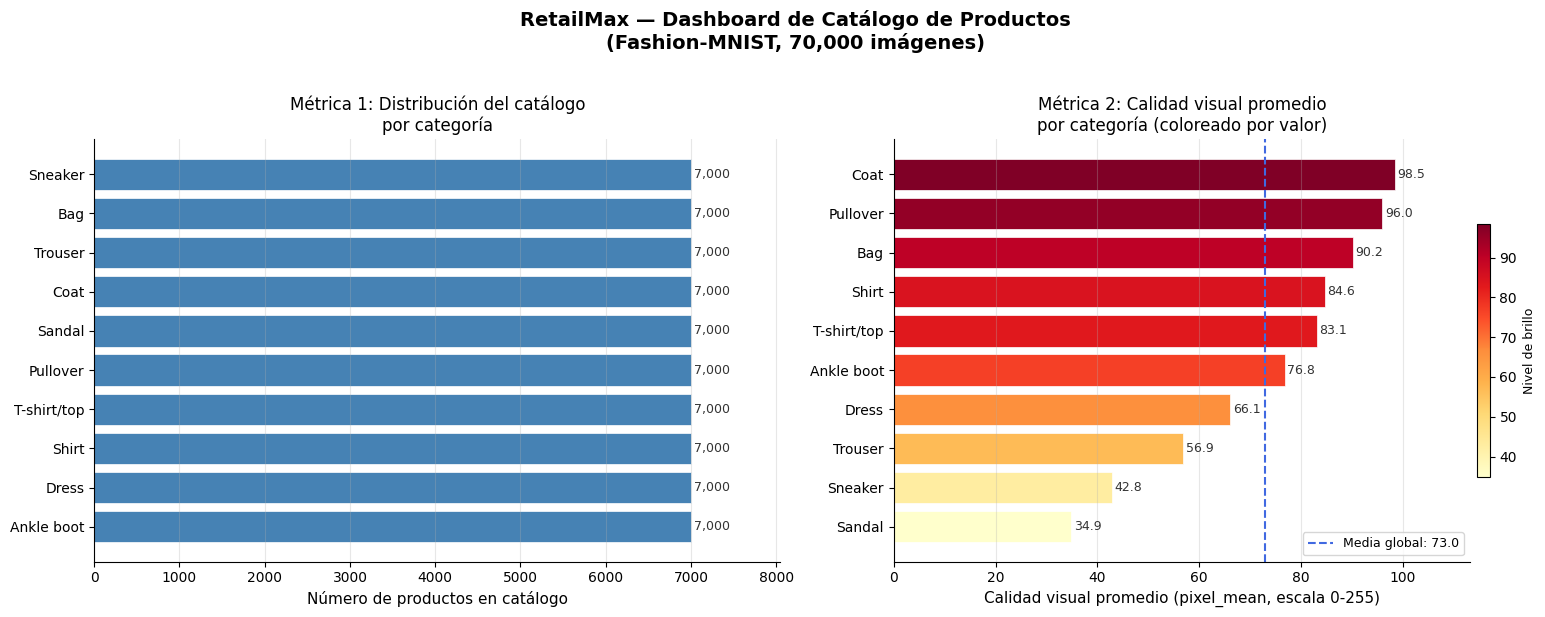

 Dashboard guardado en output/leccion4_dashboard_retailmax.png


In [11]:
# ============================================================
# SECCIÓN 4 (cont.): Visualizaciones del dashboard RetailMax
# ============================================================

# Preparar datos para visualización
pd_merged = pd_catalogo.merge(pd_calidad, on="label_name")

# Paleta de colores basada en el valor de calidad visual
calidad_vals = pd_merged["calidad_visual_promedio"].values
norm         = plt.Normalize(calidad_vals.min(), calidad_vals.max())
colores      = cm.RdYlGn(norm(calidad_vals))  # Rojo (bajo) → Verde (alto)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("RetailMax — Dashboard de Catálogo de Productos\n(Fashion-MNIST, 70,000 imágenes)",
             fontsize=14, fontweight="bold", y=1.02)

# ---- Gráfico 1: Distribución de productos por categoría ----
ax1 = axes[0]
categorias  = pd_merged["label_name"]
totales     = pd_merged["total_productos"]
bars1 = ax1.barh(categorias, totales, color="steelblue", edgecolor="white", linewidth=0.5)

# Añadir etiquetas de valor a cada barra
for bar, val in zip(bars1, totales):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", ha="left", fontsize=9, color="#333333")

ax1.set_xlabel("Número de productos en catálogo", fontsize=11)
ax1.set_title("Métrica 1: Distribución del catálogo\npor categoría", fontsize=12)
ax1.set_xlim(0, totales.max() * 1.15)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="x", alpha=0.3)

# ---- Gráfico 2: Calidad visual promedio por categoría ----
# Ordenar de menor a mayor para que el más brillante quede arriba
pd_calidad_sorted = pd_calidad.sort_values("calidad_visual_promedio")
calidad_sorted    = pd_calidad_sorted["calidad_visual_promedio"].values
norm2             = plt.Normalize(calidad_sorted.min(), calidad_sorted.max())
colores2          = cm.YlOrRd(norm2(calidad_sorted))

ax2 = axes[1]
bars2 = ax2.barh(
    pd_calidad_sorted["label_name"],
    calidad_sorted,
    color=colores2,
    edgecolor="white",
    linewidth=0.5
)

# Añadir etiquetas de valor
for bar, val in zip(bars2, calidad_sorted):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", ha="left", fontsize=9, color="#333333")

# Línea vertical: media global
ax2.axvline(media_global, color="royalblue", linestyle="--", linewidth=1.5,
            label=f"Media global: {media_global:.1f}")
ax2.legend(loc="lower right", fontsize=9)

ax2.set_xlabel("Calidad visual promedio (pixel_mean, escala 0-255)", fontsize=11)
ax2.set_title("Métrica 2: Calidad visual promedio\npor categoría (coloreado por valor)", fontsize=12)
ax2.set_xlim(0, calidad_sorted.max() * 1.15)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="x", alpha=0.3)

# Colorbar explicativa
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm2)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, shrink=0.6, pad=0.01)
cbar.set_label("Nivel de brillo", fontsize=9)

plt.tight_layout()
plt.savefig("output/leccion4_dashboard_retailmax.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Dashboard guardado en output/leccion4_dashboard_retailmax.png")

---
## Sección 5: Optimización — Catalyst y particionamiento

### ¿Qué es el Catalyst Optimizer?

**Catalyst** es el motor de optimización de Spark SQL. Transforma el plan lógico de tu consulta en un plan físico optimizado antes de ejecutarlo:

```
Tu código Python/SQL
       ↓
  Plan Lógico sin resolver  ("unresolved logical plan")
       ↓  [análisis de columnas y tipos]
  Plan Lógico resuelto
       ↓  [aplicar reglas de optimización: predicate pushdown, projection pruning...]
  Plan Lógico optimizado
       ↓  [selección de estrategias físicas: sort-merge join vs broadcast join...]
  Plan Físico
       ↓  [generación de código JVM con Tungsten]
  Ejecución
```

### Reglas clave de Catalyst

| Regla | Qué hace | Ejemplo |
|---|---|---|
| **Predicate Pushdown** | Mueve los `WHERE` lo más cerca posible de los datos | `WHERE label=0` se aplica antes de joins |
| **Projection Pruning** | Solo lee las columnas que necesitas | `SELECT label_name` no lee `pixel_std` |
| **Constant Folding** | Pre-calcula expresiones constantes | `2 + 2` → `4` en tiempo de compilación |
| **Join Reordering** | Reordena joins para reducir datos intermedios | Tabla pequeña × tabla grande → broadcast join |

### Reparticionamiento

Spark divide los datos en **particiones** que se procesan en paralelo. El número óptimo depende del hardware:
- **Pocas particiones**: workers ociosos (bajo paralelismo)
- **Muchas particiones**: overhead de scheduling
- **Regla general**: 2-4 particiones por core disponible

### cache() en DataFrames

`df.cache()` guarda el DataFrame en memoria para reusar en múltiples acciones. Sin cache, Spark recalcula el DAG completo cada vez.

In [12]:
# ============================================================
# SECCIÓN 5: Optimización — Catalyst y particionamiento
# ============================================================

# --- Paso 1: df.explain() — Ver el plan lógico y físico ---
# explain() muestra cómo Catalyst planifica ejecutar la consulta.
# Útil para depurar consultas lentas.
print("=== Paso 1: Plan de ejecución de una consulta típica ===")
print("(Plan para: GROUP BY label_name ORDER BY total DESC)\n")
df.groupBy("label_name").agg(F.count("*").alias("total")).orderBy(F.desc("total")).explain()

# --- Paso 2: Ver el número de particiones actuales ---
# Las particiones determinan el paralelismo de la operación.
n_particiones = df.rdd.getNumPartitions()
print(f"\n=== Paso 2: Número de particiones actuales: {n_particiones} ===")
print(f"   Con {n_particiones} particiones y {os.cpu_count()} CPUs disponibles,")
print(f"   cada CPU procesa aprox. {70000 // n_particiones:,} filas por partición.")

# --- Paso 3: Reparticionamiento por columna ---
# repartition(n, col) redistribuye los datos en n particiones usando hash de 'col'.
# Esto coloca registros de la misma clase en la misma partición → mejora GROUP BY.
print("\n=== Paso 3: Reparticionamiento por columna 'label' ===")
df_repart = df.repartition(4, "label")  # 4 particiones, agrupadas por label
print(f"   Particiones antes: {df.rdd.getNumPartitions()}")
print(f"   Particiones después: {df_repart.rdd.getNumPartitions()}")
print("   Ventaja: operaciones GROUP BY label serán más rápidas")
print("   porque los datos de la misma clase ya están en la misma partición.")

# --- Paso 4: cache() — medir diferencia de tiempo ---
# Primera vez (sin cache): Spark lee y procesa los datos desde cero.
# Segunda vez (con cache): Spark usa la versión en memoria.
print("\n=== Paso 4: Diferencia de tiempo con y sin cache() ===")

# Sin cache — primera ejecución
df_sin_cache = spark.createDataFrame(rows, schema=schema)  # DataFrame fresco
t0 = time.time()
_ = df_sin_cache.count()  # Primera acción — ejecuta el DAG completo
t1 = time.time()
tiempo_sin_cache = t1 - t0

# Con cache — llamar .cache() primero, luego dos count() consecutivos
df_con_cache = spark.createDataFrame(rows, schema=schema)  # DataFrame fresco
df_con_cache.cache()       # Marca para persistencia en memoria
t0 = time.time()
_ = df_con_cache.count()   # Primera acción — ejecuta DAG Y guarda en cache
t1 = time.time()
tiempo_cache_frio = t1 - t0

t0 = time.time()
_ = df_con_cache.count()   # Segunda acción — lee directamente de memoria
t1 = time.time()
tiempo_cache_caliente = t1 - t0

print(f"   Sin cache (1er count):         {tiempo_sin_cache:.3f}s")
print(f"   Con cache (1er count, frío):   {tiempo_cache_frio:.3f}s  ← incluye escritura a cache")
print(f"   Con cache (2do count, caliente): {tiempo_cache_caliente:.3f}s  ← lee desde memoria")

if tiempo_sin_cache > 0 and tiempo_cache_caliente > 0:
    mejora = tiempo_sin_cache / tiempo_cache_caliente
    print(f"    Mejora con cache: {mejora:.1f}× más rápido")

print("\n    Regla práctica: usa .cache() cuando reutilices un DataFrame")
print("   en múltiples acciones (count, show, write, toPandas).")
print("   Usa .unpersist() cuando ya no lo necesites para liberar memoria.")

# Liberar cache del DataFrame temporal
df_con_cache.unpersist()
print("   Cache liberado.")

=== Paso 1: Plan de ejecución de una consulta típica ===
(Plan para: GROUP BY label_name ORDER BY total DESC)

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [total#713L DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(total#713L DESC NULLS LAST, 4), ENSURE_REQUIREMENTS, [plan_id=892]
      +- HashAggregate(keys=[label_name#2], functions=[count(1)])
         +- Exchange hashpartitioning(label_name#2, 4), ENSURE_REQUIREMENTS, [plan_id=889]
            +- HashAggregate(keys=[label_name#2], functions=[partial_count(1)])
               +- Project [label_name#2]
                  +- Scan ExistingRDD[image_id#0,label#1,label_name#2,pixel_mean#3,pixel_std#4,pixel_max#5,pixel_min#6,split#7]



=== Paso 2: Número de particiones actuales: 12 ===
   Con 12 particiones y 12 CPUs disponibles,
   cada CPU procesa aprox. 5,833 filas por partición.

=== Paso 3: Reparticionamiento por columna 'label' ===
   Particiones antes: 12
   Particiones después: 4
   Ventaja: operacion

---
## Sección 6: Guardar en formato Parquet

### ¿Qué es Parquet?

**Apache Parquet** es un formato de archivo columnar diseñado para analytics:  

```
CSV (orientado a filas):           Parquet (orientado a columnas):

id, label, mean, std              ┌─ id: [0,1,2,3,...] ─────────┐
0, 0, 72.3, 40.1                  ├─ label: [0,1,5,3,...] ───────┤
1, 1, 51.8, 38.2                  ├─ mean: [72.3,51.8,...] ──────┤
2, 5, 88.1, 44.7                  └─ std: [40.1,38.2,...] ───────┘
```

### Ventajas sobre CSV

| Característica | CSV | Parquet |
|---|---|---|
| Compresión | Sin compresión nativa | Snappy/Gzip integrado |
| Schema | No (hay que inferirlo) | Embebido en el archivo |
| Lectura columnar | No (lee todo) | Sí (solo lee columnas necesarias) |
| Velocidad de lectura | Lenta | 2-10× más rápida para analytics |
| Legible por humanos | Sí | No (binario) |
| Compatible con | Excel, pandas | Spark, Hive, BigQuery, Athena, pandas |

### Ejemplo numérico

Para 70,000 filas × 8 columnas:
- **CSV estimado**: ~70,000 × 60 bytes/fila ≈ 4.2 MB  
- **Parquet estimado**: ~0.8-1.5 MB (compresión Snappy, 2-5× menor)

In [13]:
# ============================================================
# SECCIÓN 6: Guardar en formato Parquet
# ============================================================

# --- Paso 1: Definir ruta de salida ---
output_path = "output/leccion4_fashion_data.parquet"  # Ruta relativa al directorio de trabajo
print(f"Ruta de salida: {output_path}")

# Crear carpeta output/ si no existe
os.makedirs("output", exist_ok=True)

# --- Paso 2: Limpiar carpeta si existe (garantiza escritura limpia) ---
if os.path.exists(output_path):
    shutil.rmtree(output_path)  # Elimina la carpeta y todo su contenido
    print(f"  Carpeta anterior eliminada: {output_path}")

# --- Paso 3: Guardar el DataFrame completo en Parquet ---
# mode("overwrite"): sobrescribe si el destino ya existe
# Spark escribe múltiples archivos .parquet (uno por partición)
print("Guardando DataFrame en Parquet (esto puede tardar unos segundos)...")
t0 = time.time()
try:
    df.write.mode("overwrite").parquet(output_path)
    t1 = time.time()
    print(f"✓ Parquet guardado en {t1 - t0:.2f} segundos")
except Exception as e:
    print(f"✗ Error al guardar Parquet: {e}")
    raise

# --- Paso 4: Verificar archivos guardados ---
# Spark escribe una carpeta con múltiples archivos .parquet + _SUCCESS
print("\nContenido de la carpeta de salida:")
archivos_parquet = []
for root, dirs, files in os.walk(output_path):
    for fname in files:
        ruta_completa = os.path.join(root, fname)
        size_kb = os.path.getsize(ruta_completa) / 1024
        print(f"   {fname:<50s}  {size_kb:>8.2f} KB")
        if fname.endswith(".parquet"):
            archivos_parquet.append(ruta_completa)

# --- Paso 5: Calcular tamaño total ---
size_total_bytes = sum(os.path.getsize(f) for f in archivos_parquet)
size_total_mb    = size_total_bytes / (1024 ** 2)
print(f"\n  Archivos .parquet: {len(archivos_parquet)}")
print(f"  Tamaño total Parquet: {size_total_mb:.3f} MB")

# --- Paso 6: Leer el Parquet de vuelta ---
# Verifica que el archivo se puede leer correctamente
print("\nLeyendo Parquet de vuelta...")
df_loaded = spark.read.parquet(output_path)
print("Schema del Parquet leído:")
df_loaded.printSchema()

# --- Paso 7: Verificar que los conteos coinciden ---
count_original = df.count()
count_cargado  = df_loaded.count()
print(f"\nVerificación de integridad:")
print(f"   Filas en df original:  {count_original:,}")
print(f"   Filas en df cargado:   {count_cargado:,}")
assert count_original == count_cargado, "¡ERROR: Los conteos no coinciden!"
print(f"   ✓ Conteos coinciden — integridad verificada")

# --- Paso 8: Comparar tamaño Parquet vs estimado CSV ---
# Estimamos el tamaño CSV como: filas × bytes_promedio_por_fila
# Una fila típica: "0,0,T-shirt/top,72.3456,40.1234,254.0,0.0,train" ≈ 55-65 bytes
bytes_estimados_csv = count_original * 62  # 62 bytes promedio por fila en CSV
size_csv_mb         = bytes_estimados_csv / (1024 ** 2)
ratio_compresion    = size_csv_mb / size_total_mb if size_total_mb > 0 else 0

print(f"\n Comparativa de tamaño:")
print(f"   Tamaño estimado en CSV: {size_csv_mb:.3f} MB")
print(f"   Tamaño real en Parquet: {size_total_mb:.3f} MB")
print(f"   Ratio de compresión:    {ratio_compresion:.1f}× menor en Parquet")

print(f"\n Parquet guardado en: {output_path}")
print(f"   Tamaño: {size_total_mb:.3f} MB | Filas: {count_cargado:,} | Columnas: {len(df_loaded.columns)}")

Ruta de salida: output/leccion4_fashion_data.parquet
  Carpeta anterior eliminada: output/leccion4_fashion_data.parquet
Guardando DataFrame en Parquet (esto puede tardar unos segundos)...
✓ Parquet guardado en 13.12 segundos

Contenido de la carpeta de salida:
   .part-00000-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.55 KB
   .part-00001-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.66 KB
   .part-00002-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.66 KB
   .part-00003-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.66 KB
   .part-00004-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.55 KB
   .part-00005-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.66 KB
   .part-00006-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.66 KB
   .part-00007-2dbe4f9a-20a5-48f1-9fd7-d9ad74396731-c000.snappy.parquet.crc      0.66 KB
   .part-00008-2dbe4f9a-20a

---
## Sección 7: Guardar métricas en Parquet

Además del DataFrame completo, guardamos las **métricas agregadas** en un Parquet separado.  
Este archivo será el punto de entrada de la **Lección 5 (MLlib)**, donde construiremos el pipeline de Machine Learning sobre datos ya pre-procesados y agregados.

In [14]:
# ============================================================
# SECCIÓN 7: Guardar métricas en Parquet
# ============================================================

metricas_path = "output/leccion4_metricas.parquet"

# Construir el DataFrame de métricas completo
# Incluye: distribución, calidad visual, contraste y productos de alta calidad
print("Construyendo DataFrame de métricas para Lección 5...")

df_metricas = spark.sql(f"""
    SELECT
        label_name,
        COUNT(*)                                                   AS total_productos,
        ROUND(AVG(pixel_mean),  4)                                 AS calidad_visual_promedio,
        ROUND(AVG(pixel_std),   4)                                 AS contraste_promedio,
        ROUND(MAX(pixel_mean),  4)                                 AS calidad_maxima,
        ROUND(MIN(pixel_mean),  4)                                 AS calidad_minima,
        SUM(CASE WHEN pixel_mean > {media_global:.4f} THEN 1 ELSE 0 END) AS productos_alta_calidad,
        ROUND(AVG(pixel_max),   4)                                 AS brillo_pico_promedio,
        ROUND(AVG(pixel_min),   4)                                 AS sombra_promedio
    FROM fashion_data
    GROUP BY label_name
    ORDER BY total_productos DESC
""")

print("\nDataFrame de métricas:")
df_metricas.show(truncate=False)

# Limpiar carpeta anterior si existe
if os.path.exists(metricas_path):
    shutil.rmtree(metricas_path)

# Guardar en Parquet
print(f"Guardando métricas en: {metricas_path}")
try:
    df_metricas.write.mode("overwrite").parquet(metricas_path)
    print(f" Métricas guardadas")
except Exception as e:
    print(f" Error al guardar métricas: {e}")
    raise

# Verificar que se guardó correctamente
df_metricas_cargado = spark.read.parquet(metricas_path)
n_metricas          = df_metricas_cargado.count()
print(f"\nVerificación:")
print(f"   Filas guardadas: {n_metricas} (una por cada una de las 10 categorías)")
print(f"   Columnas: {df_metricas_cargado.columns}")

# Calcular tamaño
size_metricas = sum(
    os.path.getsize(os.path.join(r, f))
    for r, dirs, files in os.walk(metricas_path)
    for f in files if f.endswith(".parquet")
)
print(f"   Tamaño del Parquet de métricas: {size_metricas/1024:.2f} KB")
print(f"\n Parquet de métricas guardado en: {metricas_path}")
print(f"   → Será cargado por la Lección 5 para el pipeline de MLlib")

Construyendo DataFrame de métricas para Lección 5...

DataFrame de métricas:
+-----------+---------------+-----------------------+------------------+--------------+--------------+----------------------+--------------------+---------------+
|label_name |total_productos|calidad_visual_promedio|contraste_promedio|calidad_maxima|calidad_minima|productos_alta_calidad|brillo_pico_promedio|sombra_promedio|
+-----------+---------------+-----------------------+------------------+--------------+--------------+----------------------+--------------------+---------------+
|Ankle boot |7000           |76.7749                |91.7755           |143.4923      |15.4477       |3900                  |254.9337            |0.0            |
|Dress      |7000           |66.0726                |85.6188           |156.9452      |9.8355        |2703                  |254.9203            |0.0            |
|Shirt      |7000           |84.6413                |76.5219           |191.8202      |9.9962        |4320  

---
## Sección 8: Cerrar Spark e Informe final

In [15]:
# ============================================================
# SECCIÓN 8: Cerrar SparkSession
# ============================================================

# Detener la SparkSession — libera todos los recursos del cluster
# Es importante siempre cerrar Spark al final para evitar fugas de memoria.
spark.stop()
print(" SparkSession cerrada correctamente")
print("  Todos los recursos del cluster han sido liberados.")

 SparkSession cerrada correctamente
  Todos los recursos del cluster han sido liberados.


---
##  Resumen de la Lección 4

### Tabla de operaciones

| Operación | Código | Para qué sirve en RetailMax |
|---|---|---|
| Definir schema | `StructType([StructField(...)])` | Garantizar tipos de columna en el catálogo |
| Crear DataFrame | `spark.createDataFrame(data, schema)` | Cargar el catálogo de 70K productos |
| Ver schema | `df.printSchema()` | Auditar la estructura de datos |
| Seleccionar columnas | `df.select("col1", "col2")` | Extraer solo los campos necesarios |
| Filtrar filas | `df.filter(df.label == 0)` | Filtrar por categoría de producto |
| Agregar columna | `df.withColumn("brightness", F.when(...))` | Clasificar imágenes por calidad |
| Agrupar y agregar | `df.groupBy().agg(F.count(), F.avg())` | Métricas por categoría |
| Registrar vista SQL | `df.createOrReplaceTempView("nombre")` | Exponer datos a analistas SQL |
| Consulta SQL | `spark.sql("SELECT ...")` | KPIs del dashboard RetailMax |
| Ver plan de ejecución | `df.explain()` | Depurar consultas lentas |
| Reparticionar | `df.repartition(4, "label")` | Optimizar GROUP BY por categoría |
| Cache | `df.cache()` | Reusar DataFrame en múltiples operaciones |
| Convertir a pandas | `df.toPandas()` | Visualizaciones con matplotlib |
| Guardar Parquet | `df.write.mode("overwrite").parquet(path)` | Persistir resultados para Lección 5 |
| Leer Parquet | `spark.read.parquet(path)` | Cargar datos en lecciones posteriores |

---

### Archivos generados en `output/`

```
output/
├── leccion4_fashion_data.parquet/    ← DataFrame completo (70,000 filas, 9 columnas)
│   ├── part-00000-*.parquet          ← Datos (uno por partición)
│   └── _SUCCESS                      ← Marcador de escritura exitosa
├── leccion4_metricas.parquet/        ← Métricas agregadas (10 filas, una por clase)
│   ├── part-00000-*.parquet
│   └── _SUCCESS
└── leccion4_dashboard_retailmax.png  ← Gráficos del dashboard
```

---

###  Conexión con la Lección 5

En la **Lección 5 (MLlib)** cargaremos el Parquet que acabamos de generar:

```python
# Así empezará la Lección 5:
df = spark.read.parquet("output/leccion4_fashion_data.parquet")
metricas = spark.read.parquet("output/leccion4_metricas.parquet")

# Y construiremos el pipeline de MLlib:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
```

El DataFrame estructurado que creamos hoy — con `pixel_mean`, `pixel_std`, `pixel_max`, `pixel_min` — será el **vector de features** del modelo de clasificación de prendas.

---

###  Checklist de entregables

- [x] **DataFrame creado** — 70,000 filas con schema explícito
- [x] **SQL ejecutado** — 4 consultas de negocio con interpretación
- [x] **Métricas de negocio** — Dashboard RetailMax con 4 KPIs
- [x] **Visualizaciones** — 2 gráficos matplotlib del dashboard
- [x] **Optimización** — explain(), repartition(), cache() demostrados
- [x] **Parquet guardado** — `leccion4_fashion_data.parquet` (datos completos)
- [x] **Métricas en Parquet** — `leccion4_metricas.parquet` (para Lección 5)

---

*Lección 4 completada — Módulo 9: Retail Analytics Pipeline*  
*Próxima parada: **Lección 5 — MLlib: Pipeline de Machine Learning distribuido***